Publication-ready trade-level statistics

 Final model loaded: quantum_alpha_final.pth

=== TRADE LOG ANALYSIS ===
                      Metric     Value
0               Total Trades  188.0000
1               Win Rate (%)   35.6400
2                    Avg Win    0.0061
3                   Avg Loss   -0.0042
4              Profit Factor    0.8081
5  Avg Trade Duration (days)    3.9000


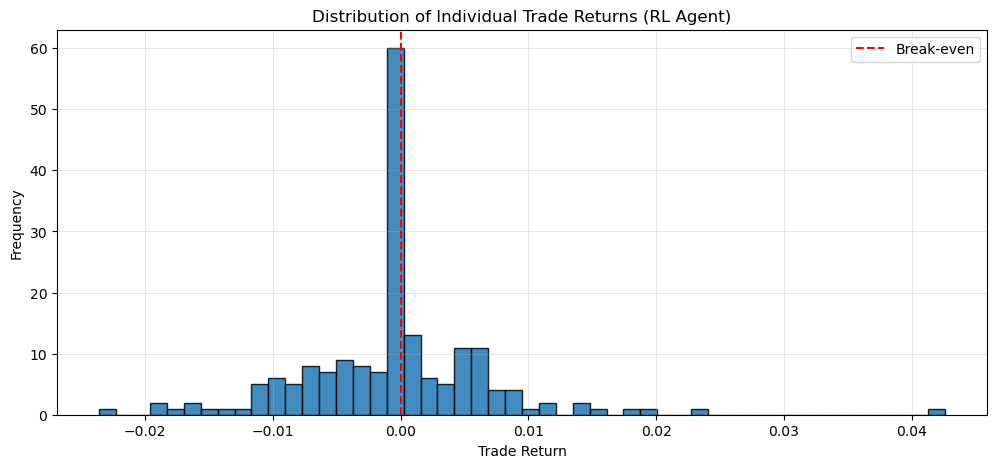

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Publication-ready trade-level statistics\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. FINAL DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()
print(" Final model loaded: quantum_alpha_final.pth")

# =============================================
# 2. ENVIRONMENT
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# =============================================
# 3. RUN RL AGENT & GENERATE TRADE LOG
# =============================================
test_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
test_data = test_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])
test_data = test_data.loc["2023":"2025"]

env = QuantumAlphaEnv(test_data)
state = env.reset()
done = False
positions = []
returns = []
dates = test_data.index

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()
    next_state, net_ret, done, info = env.step(action)
    positions.append(info["position"])
    returns.append(net_ret)
    state = next_state

positions = np.array(positions)
returns = np.array(returns)
dates = dates[:len(positions)]

# Identify trades (position change)
trade_id = (np.diff(np.concatenate(([0], positions))) != 0).cumsum()
trade_log = pd.DataFrame({
    "Date": dates,
    "Position": positions,
    "Return": returns
})
trade_log["Trade_ID"] = trade_id

# Aggregate per trade
trade_returns = trade_log.groupby("Trade_ID")["Return"].sum()
trade_duration = trade_log.groupby("Trade_ID").size()

# =============================================
# 4. TRADE STATISTICS
# =============================================
win_rate = (trade_returns > 0).mean()
avg_win = trade_returns[trade_returns > 0].mean()
avg_loss = trade_returns[trade_returns < 0].mean()
profit_factor = abs(trade_returns[trade_returns > 0].sum()) / abs(trade_returns[trade_returns < 0].sum()) if len(trade_returns[trade_returns < 0]) > 0 else np.inf
total_trades = len(trade_returns)
avg_duration = trade_duration.mean()

trade_stats = pd.DataFrame({
    "Metric": ["Total Trades", "Win Rate (%)", "Avg Win", "Avg Loss", "Profit Factor", "Avg Trade Duration (days)"],
    "Value": [total_trades, round(win_rate*100, 2), round(avg_win, 4), round(avg_loss, 4), round(profit_factor, 4), round(avg_duration, 1)]
})
print("\n=== TRADE LOG ANALYSIS ===")
print(trade_stats)

# =============================================
# 5. TRADE RETURN DISTRIBUTION
# =============================================
plt.figure(figsize=(12, 5))
plt.hist(trade_returns, bins=50, color="#1f77b4", edgecolor="black", alpha=0.85)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Break-even")
plt.title("Distribution of Individual Trade Returns (RL Agent)")
plt.xlabel("Trade Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()